In [147]:
%run "/home/nichettg/Codici/Laboratorio/moduli.py"

In [148]:
def nome (stringa):
    """
    Estrae il nome, cioè la frequenza, dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace('./Data/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [149]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [150]:
gf.display_dizionario(dati)

# 2. Analisi Oscillazione Forzata

## 2.1 Grafici Confronto Oscillazione

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


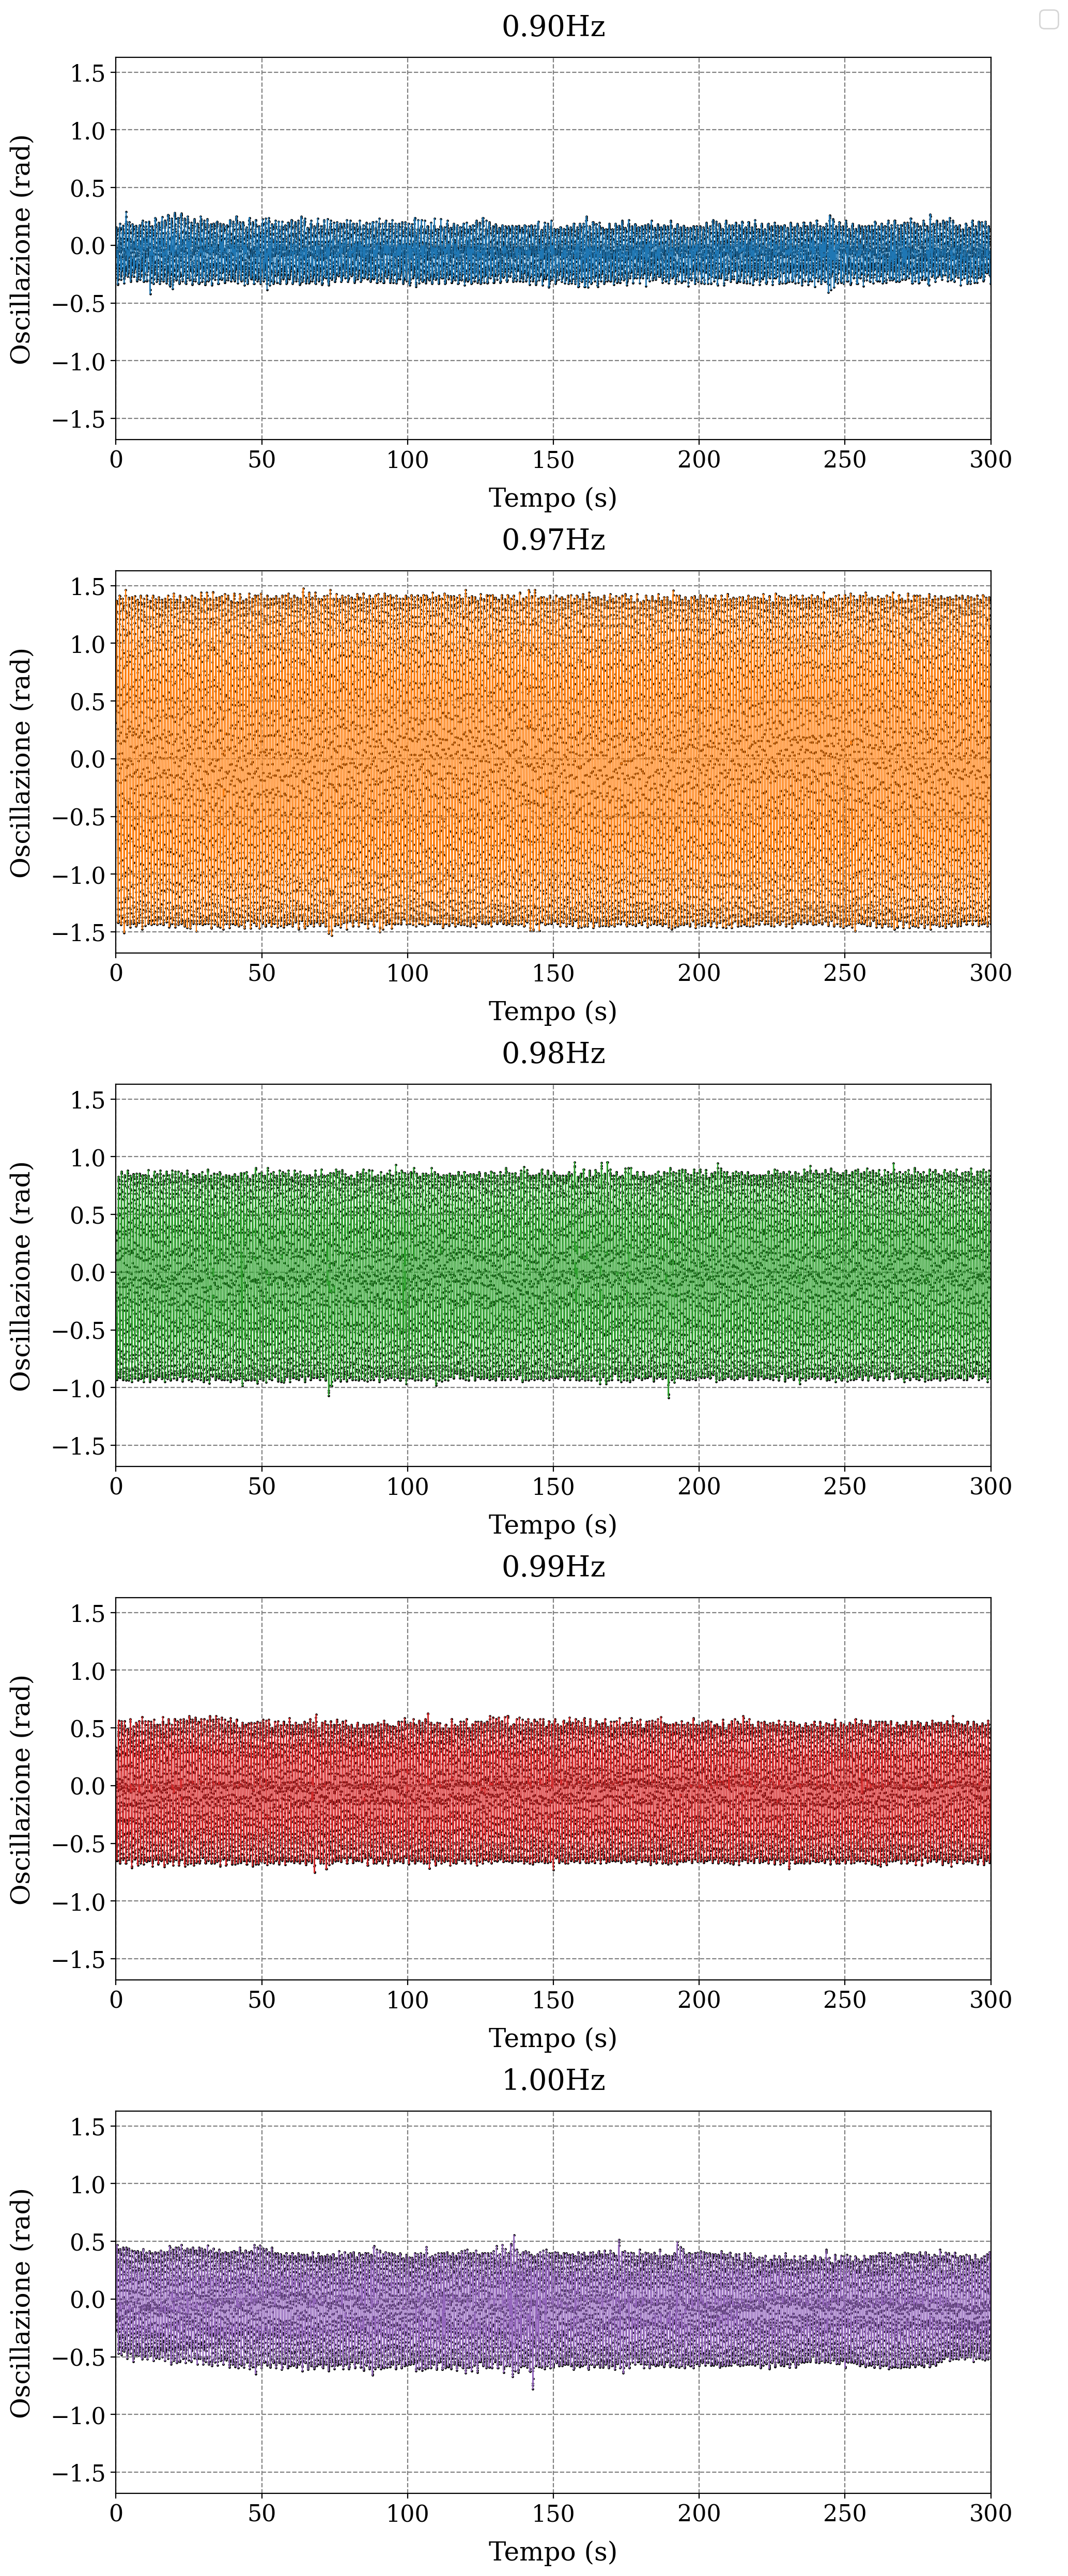

In [151]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/ConfrontoForzanti.pdf")

## 2.2 Calcolo Ampiezze Oscillazione

Raggio dell'intorno rispetto al quale i valori salvati sono i massimi. Di tali valori verrà poi calcolata la media, considerata come ampiezza media.

In [152]:
grafico_controllo = True

Vengono trovati massimi e minimi delle oscillazioni, viene poi fatta la media dei minimi e dei massimi singolarmente per poi fare la media tra i due. Vengono supposti gaussiani il campione dei massimi e quello dei minimi, considerando poi come ampiezza di oscillazione la media tra i due.

Serie 0.90Hz: 209 massimi e 233 minimi trovati 
 Periodo = 1.11 s 
 Intorno = 54
Serie 0.97Hz: 259 massimi e 247 minimi trovati 
 Periodo = 1.03 s 
 Intorno = 50
Serie 0.98Hz: 243 massimi e 244 minimi trovati 
 Periodo = 1.02 s 
 Intorno = 50
Serie 0.99Hz: 242 massimi e 225 minimi trovati 
 Periodo = 1.01 s 
 Intorno = 50
Serie 1.00Hz: 252 massimi e 242 minimi trovati 
 Periodo = 1.00 s 
 Intorno = 50


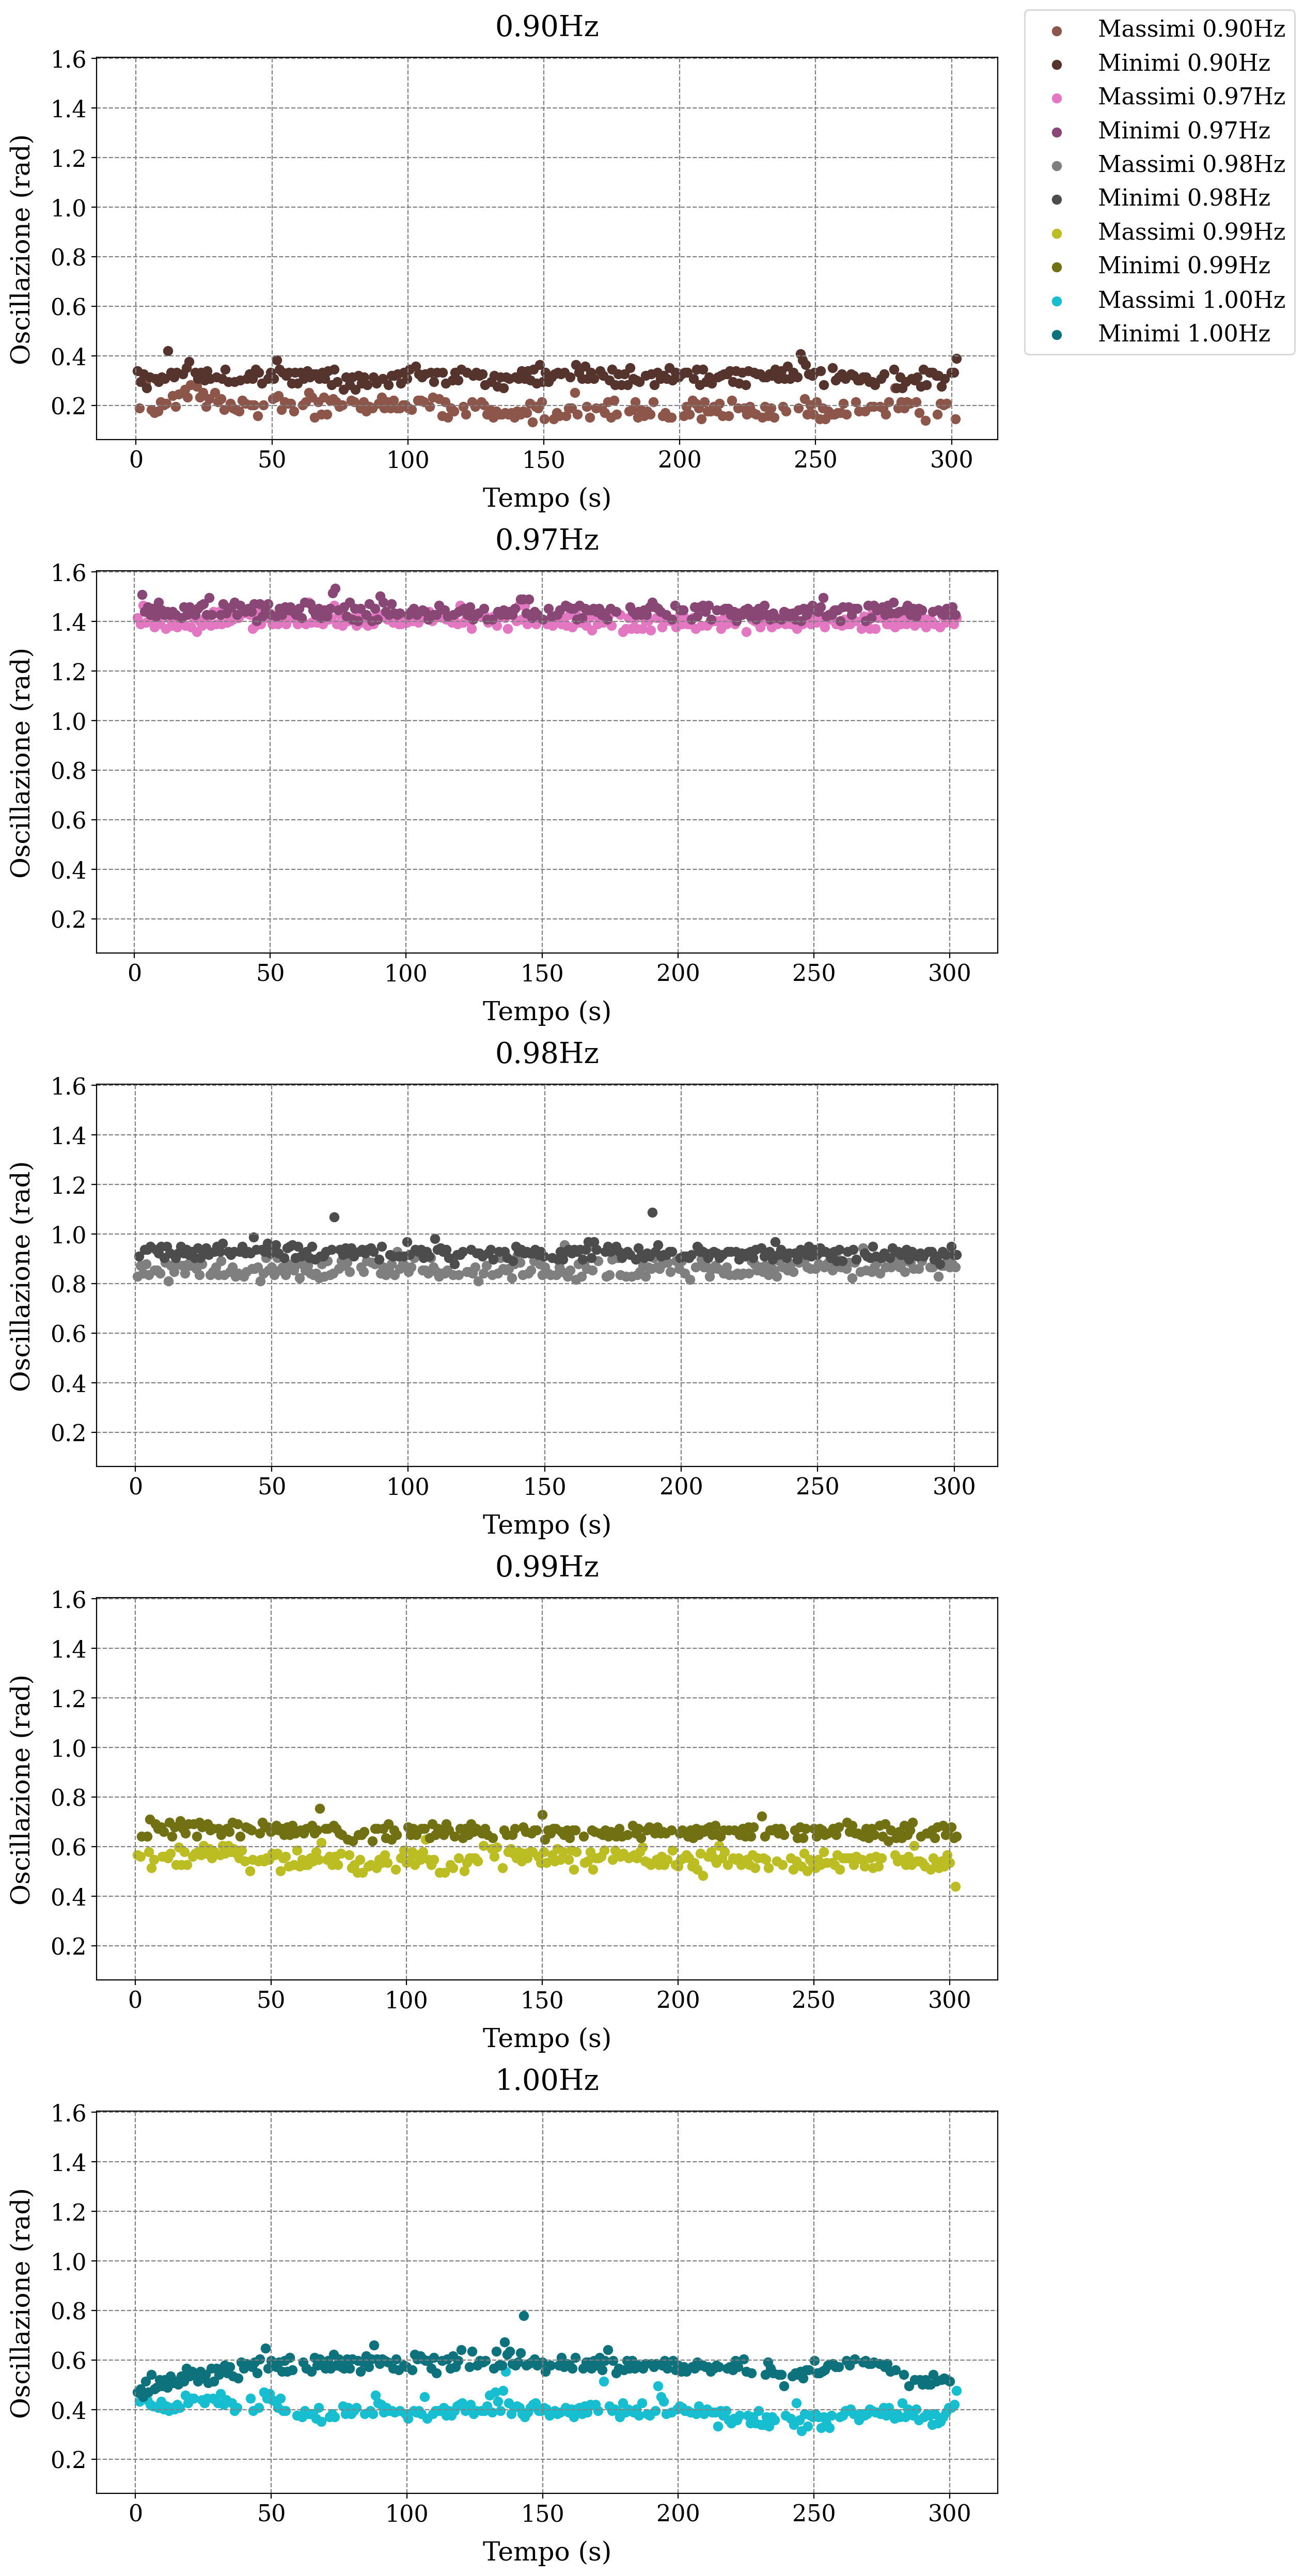

In [153]:
ampiezze = {}

if grafico_controllo: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati.keys()):
    valori = dati[serie]["pendolo"] * (2*np.pi)
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = int((periodo / 2) * 50)

    fine_forzante = np.argmin(abs(dati[titolo]["forzante"]))

    for j, val in enumerate(valori):
        if j > fine_forzante:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        # Massimi
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])
        # Minimi
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(abs(val))
            minimi_t.append(tempi[j])

    ampiezze[serie] = (np.mean(massimi) + np.mean(minimi)) / 2

    print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")
    
    if grafico_controllo:
        ax = axes[i]
        colore = next(color_cycle)
        ax.scatter(massimi_t, massimi, color=colore, label=f"Massimi {serie}")
        ax.scatter(minimi_t, minimi, color=gf.darken(colore), label=f"Minimi {serie}")
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Oscillazione (rad)")

if grafico_controllo: gf.salva_grafico(fig, f"./Images/ConfrontoMassimi.pdf")

In [154]:
gf.display_dizionario(ampiezze)


0.90Hz,0.25499562507817913
0.97Hz,1.4219566899906009
0.98Hz,0.8945074692724654
0.99Hz,0.6060107996104105
1.00Hz,0.4838253595149379


## 2.3 Fit Lorentziano

---

$$
L(x) = \frac{A}{(B + x^2)^2 + C x^2}
$$

dove:

- ( $A$ ): costante di scala, legata all'altezza del picco  
- ( $B = \omega_0^2$ ): frequenza di risonanza, corrisponde alla posizione del picco  
- ( $C = \gamma^2$ ): larghezza a metà altezza (HWHM), legata allo smorzamento del sistema

$$
L(x) = \frac{A}{(\omega_0^2 + x^2)^2 + \gamma^2 x^2}
$$

---

Seleziona se eseguire o no il fit lorentziano.

In [155]:
fit_lorentziano = True

Fit lorentziano:

A: $(37.0 \pm 5.5) \times 10^{-4}$

B: $(-918.3 \pm 6.2) \times 10^{-3}$

C: $(22.5 \pm 3.8) \times 10^{-4}$

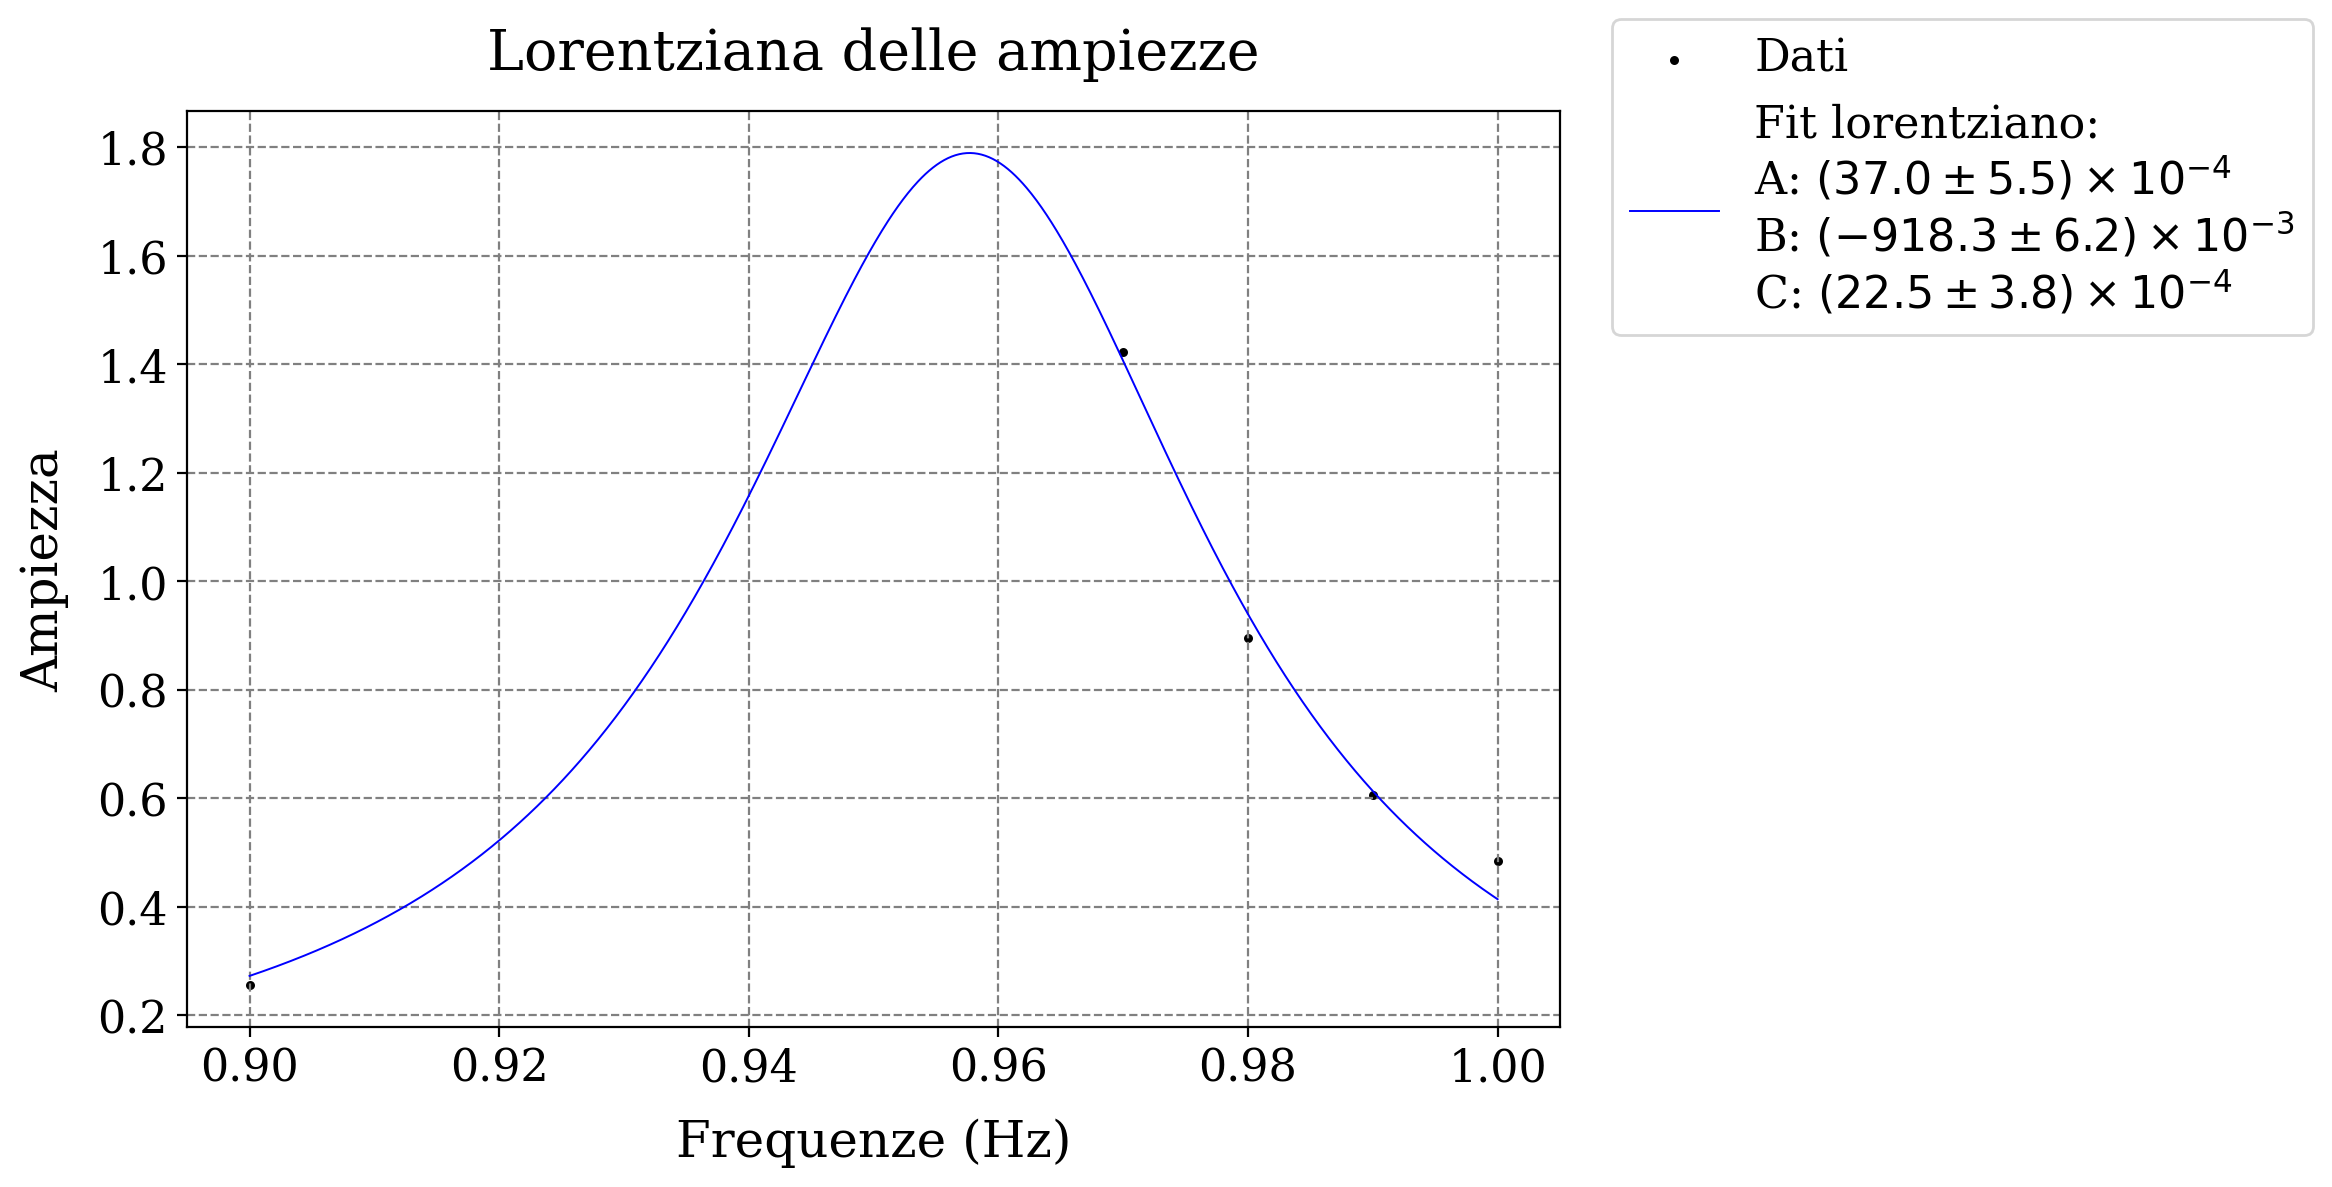

In [156]:
from scipy.optimize import curve_fit
from IPython.display import display, Markdown

def lorentziana(x, A, B, C):
    return A / ((x**2 + B)**2 + C * x**2)

frequenze = [float(key.replace('Hz', '')) for key in dati.keys()]
ampiezze_valori = list(ampiezze.values())

fig, ax = plt.subplots()
ax.scatter(frequenze, ampiezze_valori, color='black', label='Dati', s=5)

if fit_lorentziano:

    A0 = max(ampiezze_valori)
    B0 = np.mean(frequenze)**2
    C0 = 10

    p0 = [A0, B0, C0]
    popt, pcov = curve_fit(
        lorentziana,
        frequenze,
        ampiezze_valori,
        p0=p0
    )
    perr = np.sqrt(np.diag(pcov))

    label = [
        "Fit lorentziano:",
        rf"A: {gf.formatta_errore(popt[0], perr[0])}",
        rf"B: {gf.formatta_errore(popt[1], perr[1])}",
        rf"C: {gf.formatta_errore(popt[2], perr[2])}",
    ]

    x_fit = np.linspace(min(frequenze), max(frequenze), 1000)
    y_fit = lorentziana(x_fit, *popt)
    ax.plot(x_fit, y_fit, color='blue', linewidth=0.7, label='\n'.join(label))

    display(Markdown('\n\n'.join(label)))

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (Hz)", "Ampiezza")
gf.salva_grafico(fig, "./Images/Lorentziana.pdf")

# 3. Analisi Oscillazione Smorzata

## 3.1 Grafici Confronto Oscillazione

Tempo in cui vengono tagliati i dati.

In [164]:
fine = 420

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


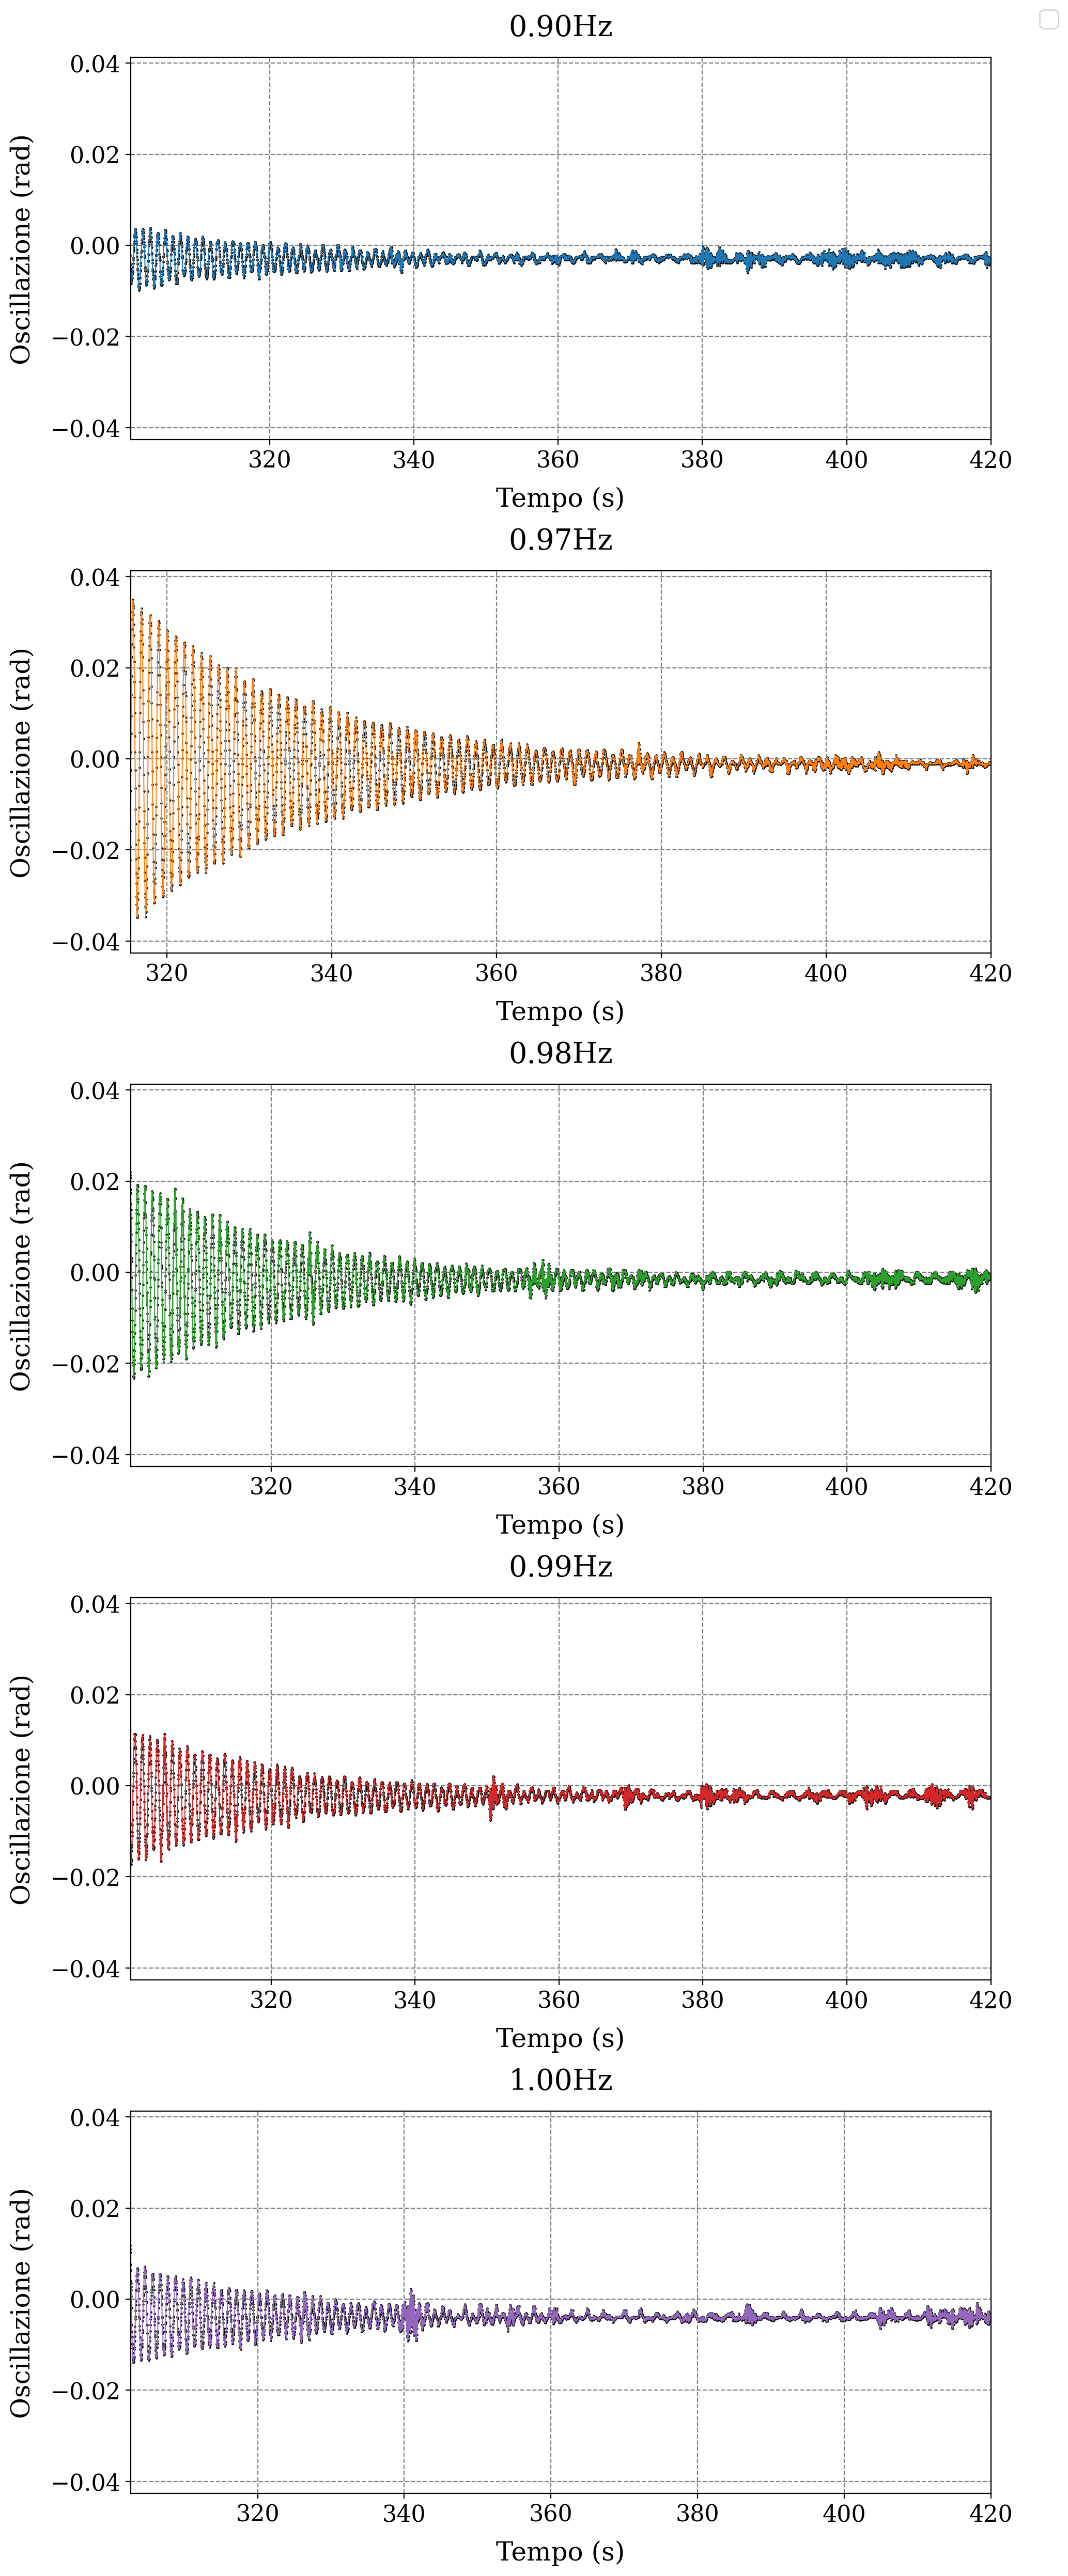

In [186]:
dati_tagliati = {}
fig, axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):
    ax = axes[i]
    
    titolo = nome(input_file)
    colore = next(color_cycle_fisso)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] / (2 * np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")

    # Calcolo indice di fine oscillazione forzante (inizio smorzamento)
    fine_forzante = np.argmin(np.abs(dati[titolo]["forzante"]))
    fine_taglio = np.searchsorted(dati[titolo]["tempo"], fine)

    ax.set_xlim(x[fine_forzante], x[fine_taglio])

    # Taglio i dati SOLO per la serie corrente
    dati_tagliati[titolo] = {
        "tempo": dati[titolo]["tempo"][fine_forzante:fine_taglio].reset_index(drop=True),
        "pendolo": dati[titolo]["pendolo"][fine_forzante:fine_taglio].reset_index(drop=True),
    }

gf.salva_grafico(fig, "./Images/ConfrontoSmorzati.pdf")

In [187]:
gf.display_dizionario(dati_tagliati)

## 3.2 Calcolo Ampiezze Oscillazione

In [189]:
grafico_controllo_2 = True

Serie 0.90Hz: 48 massimi e 52 minimi trovati 
 Periodo = 1.11 s 
 Intorno = 54
Serie 0.97Hz: 68 massimi e 60 minimi trovati 
 Periodo = 1.03 s 
 Intorno = 50
Serie 0.98Hz: 59 massimi e 68 minimi trovati 
 Periodo = 1.02 s 
 Intorno = 50
Serie 0.99Hz: 58 massimi e 58 minimi trovati 
 Periodo = 1.01 s 
 Intorno = 50
Serie 1.00Hz: 57 massimi e 59 minimi trovati 
 Periodo = 1.00 s 
 Intorno = 50


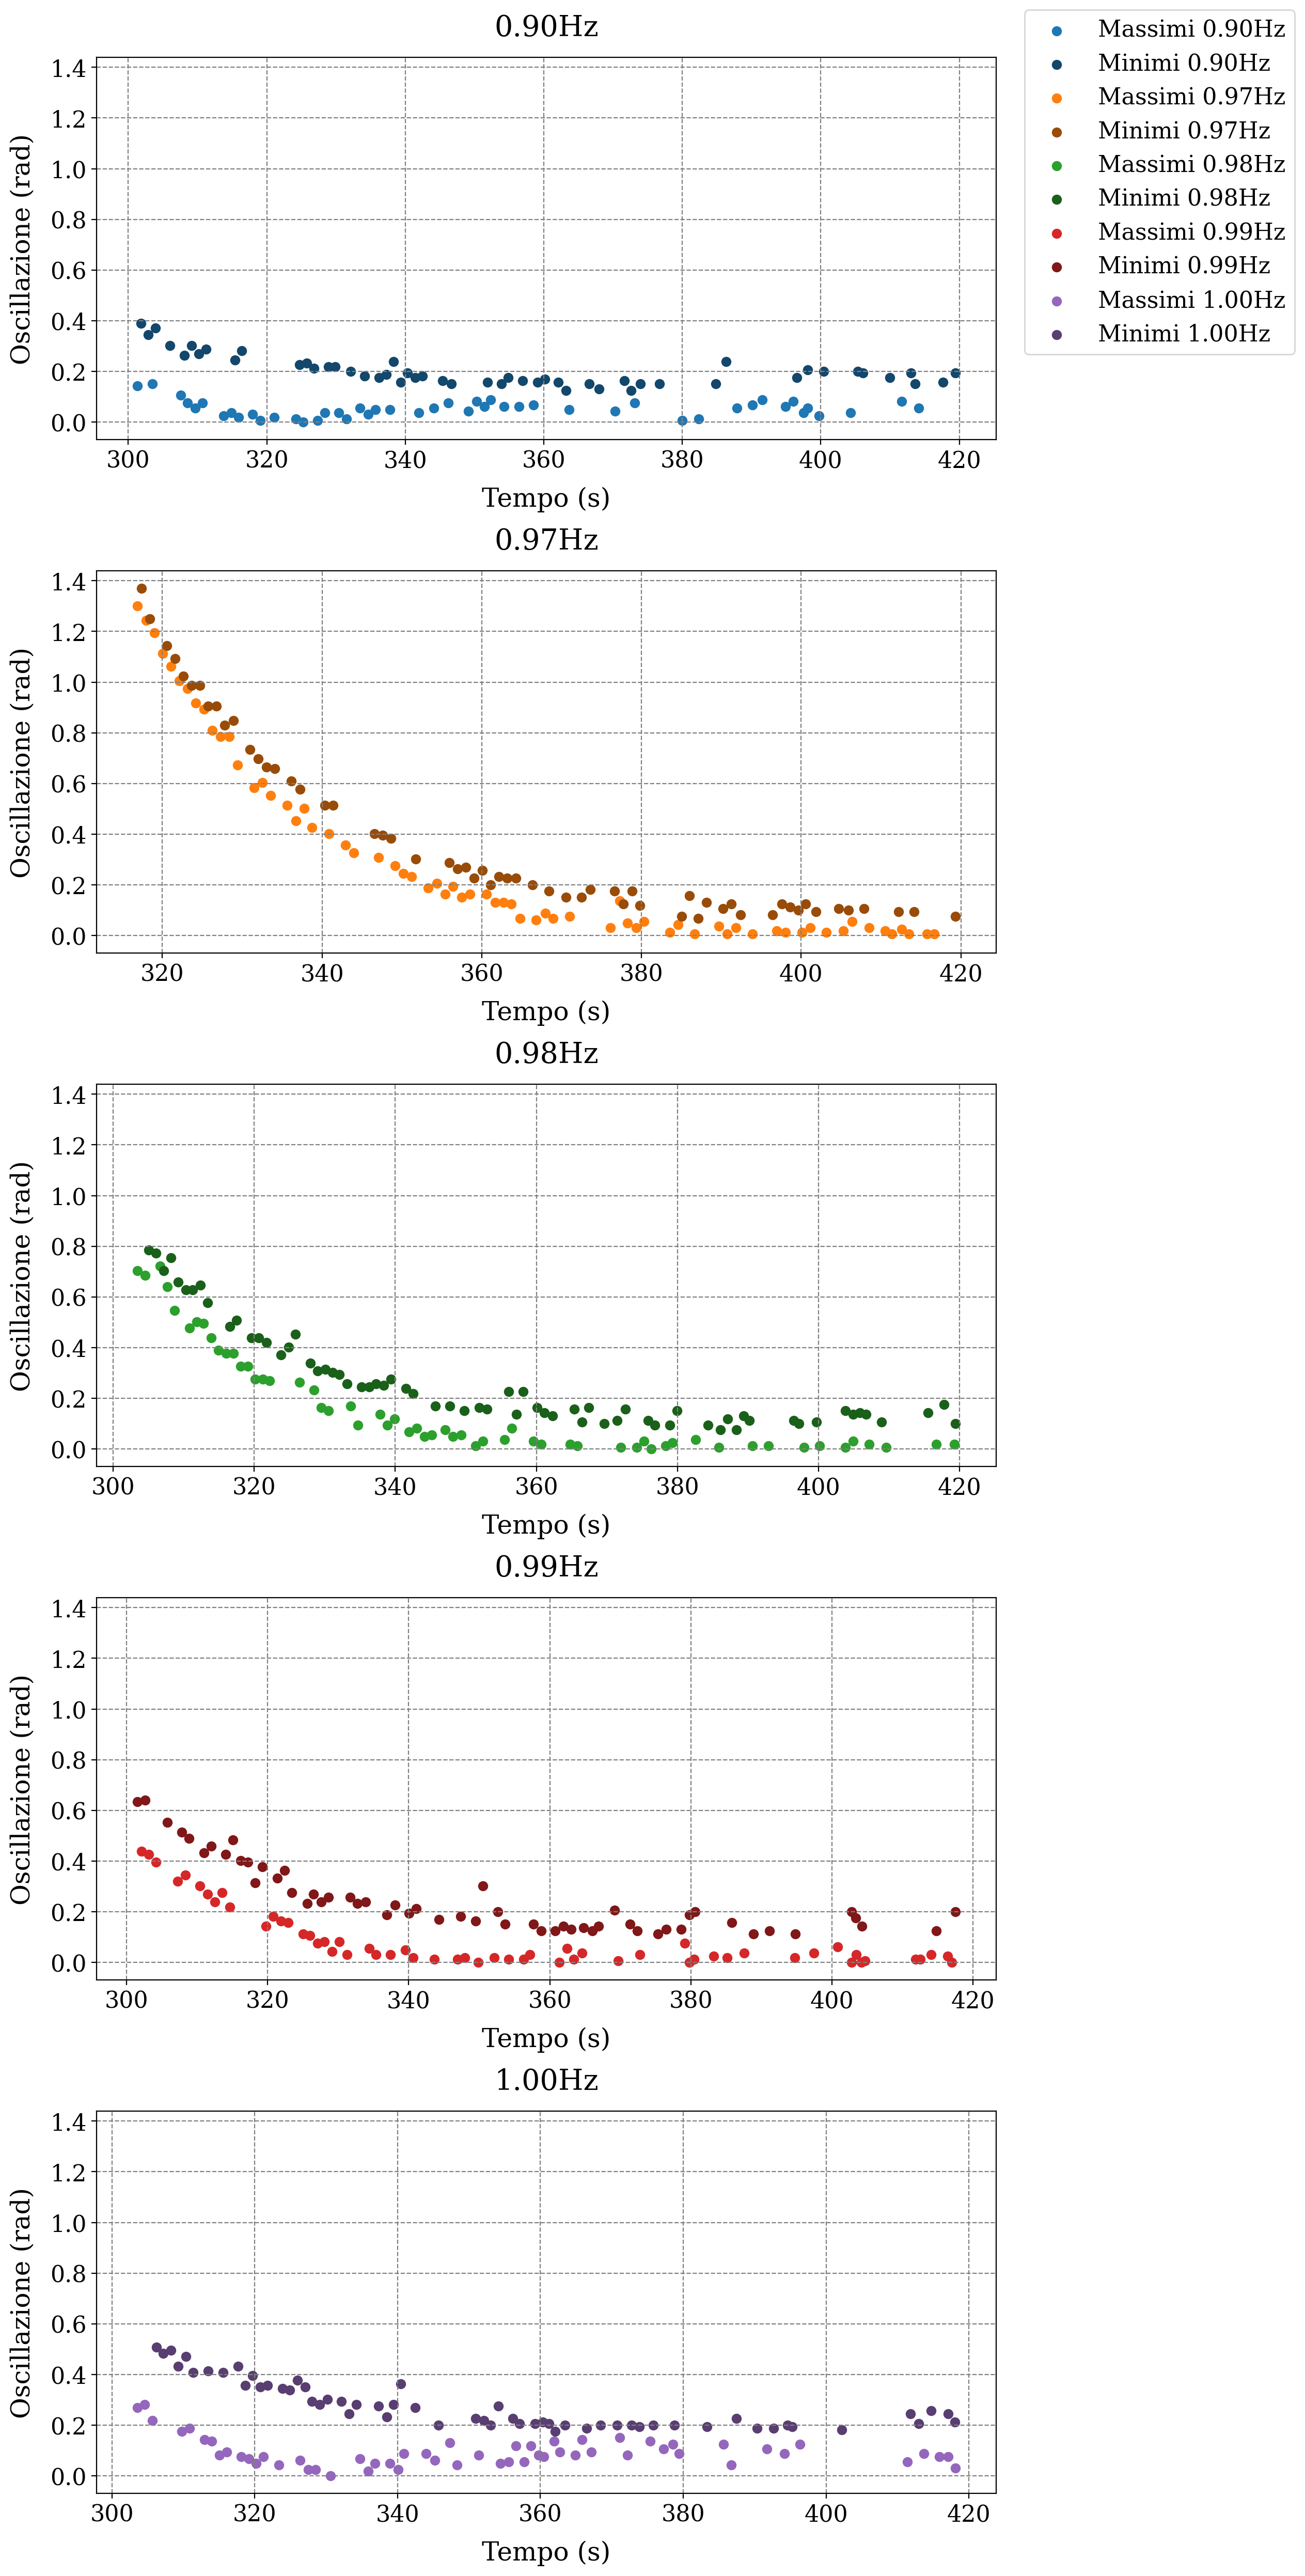

In [194]:
tagliati = {}

if grafico_controllo_2: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati_tagliati.keys()):
    valori = dati_tagliati[serie]["pendolo"] * (2*np.pi)
    tempi = dati_tagliati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = max(1, int((periodo / 2) * 50))  # almeno 1

    for j, val in enumerate(valori):
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(abs(val))
            minimi_t.append(tempi[j])

    tagliati[serie] = {
        "tempo_minimi" : minimi_t,
        "minimi" : minimi,
        "tempo_massimi" : massimi_t,
        "massimi" : massimi,
    }

    print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")
    
    if grafico_controllo_2:
        ax = axes[i]
        colore = next(color_cycle)
        ax.scatter(massimi_t, massimi, color=colore, label=f"Massimi {serie}")
        ax.scatter(minimi_t, minimi, color=gf.darken(colore), label=f"Minimi {serie}")
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Oscillazione (rad)")
if grafico_controllo_2: gf.salva_grafico(fig, f"./Images/ConfrontoMassimiSmorzamento.pdf")

In [195]:
gf.display_dizionario(tagliati)

## 3.3 File Output

In [198]:
for serie in tagliati.keys():
    file_output = f"./Smorzamento/{serie}.csv"
    with open(file_output, 'w') as f:
        # Intestazione opzionale
        f.write("tempo_minimi,minimi,tempo_massimi,massimi\n")
        
        # Estrai le serie
        tm = tagliati[serie]["tempo_minimi"]
        m = tagliati[serie]["minimi"]
        tM = tagliati[serie]["tempo_massimi"]
        M = tagliati[serie]["massimi"]

        for valori in zip(tm, m, tM, M):
            f.write(",".join(map(str, valori)) + "\n")